# **Activity: Linear filters**

Jesús David Petro Ramos - T00065696 
<!-- Aliveette Zambrano Mercado - T00067935 \ -->
Universidad Tecnológica de Bolívar

Link del repo donde he estado realizando la actividad: [Repo](https://github.com/JesusPetro/Vision-Artificial-2P2025/blob/main/semana%205/T00065696_work4.ipynb)
<!-- Based on the jupyter notebook by [Vince Knight](https://github.com/drvinceknight/Python-Mathematics-Handbook) -->


## __Introducción__

El procesamiento digital de imágenes permite **atenuar ruido, resaltar bordes y controlar artefactos en los bordes** de la imagen mediante filtrado espacial. En este trabajo se usan kernels simples (promedio 3×3 y Gaussiano) y operadores de realce/detección de bordes (Prewitt, Sobel, Laplaciano y *unsharp mask*), poniendo especial atención a cómo las **condiciones de frontera** y el **tamaño/forma del kernel** impactan el resultado visual y el tamaño de la salida.

En este laboratorio **aprendimos** a:
- Implementar y documentar una función de **suavizado Gaussiano** y un **filtro promedio 3×3** (normalizado 1/9).
- Explorar con `scipy.signal.convolve2d` la interacción entre `mode` (**full / same / valid**) y `boundary` (**fill / wrap / symm**), observando cambios en **dimensiones de salida** y **artefactos de borde**.
- Generar ruido controlado con `skimage.util.random_noise` (**gaussian, localvar, poisson, salt**) y comparar **Gaussiano vs. Mediana** (ventana disco) para limpieza: la mediana preserva mejor bordes ante ruido impulsivo (*salt*), mientras el Gaussiano suaviza de forma global.
- Aplicar **Prewitt/Sobel** para resaltar gradientes, **Laplaciano** para realce por segunda derivada, y **unsharp mask** para aumentar contraste local, notando su tendencia a **amplificar ruido** si el suavizado previo es insuficiente.

Con estas pruebas —sobre una imagen de ejemplo y salidas anotadas con sus *shapes*— se estableció una base práctica para **seleccionar filtros según el objetivo** (suavizar, detectar bordes o realzar), **elegir parámetros con criterio** y **anticipar efectos de borde** al diseñar *pipelines* reproducibles de visión por computador.


In [47]:
# Importamos las librerias necesarias
from scipy.ndimage import gaussian_filter
from skimage.morphology import disk
from scipy import signal, datasets
import matplotlib.pyplot as plt
import numpy as np
import skimage

## __Brief Theory of Linear Filters__

Aplicamos una **convolución 2D** con un filtro de suavizado sobre una imagen y comparamos los resultados variando dos opciones: `mode` (≈ *modo de salida*: `full`, `same`, `valid`, que cambia el tamaño de la imagen resultante) y `boundary` (≈ *condición de borde*: `fill`, `wrap`, `symm`, que define cómo se tratan los bordes). Para cada combinación generamos la imagen filtrada, la mostramos en una grilla y anotamos su `shape` (tamaño), de modo que, de forma **muy general**, se vea cómo estas configuraciones afectan el resultado sin entrar en detalles matemáticos.


In [6]:
def apply_gaussian_filter(img, sigma=1):
    """
    Apply a Gaussian filter to an image.

    Parameters
    ----------
    img : ndarray
        Input image.
    sigma : float, optional
        Standard deviation for Gaussian kernel (default is 1).

    Returns
    -------
    ndarray
        Smoothed image after applying Gaussian filter.
    """
    return gaussian_filter(img, sigma=sigma)


Tamaño Original: (512, 512)


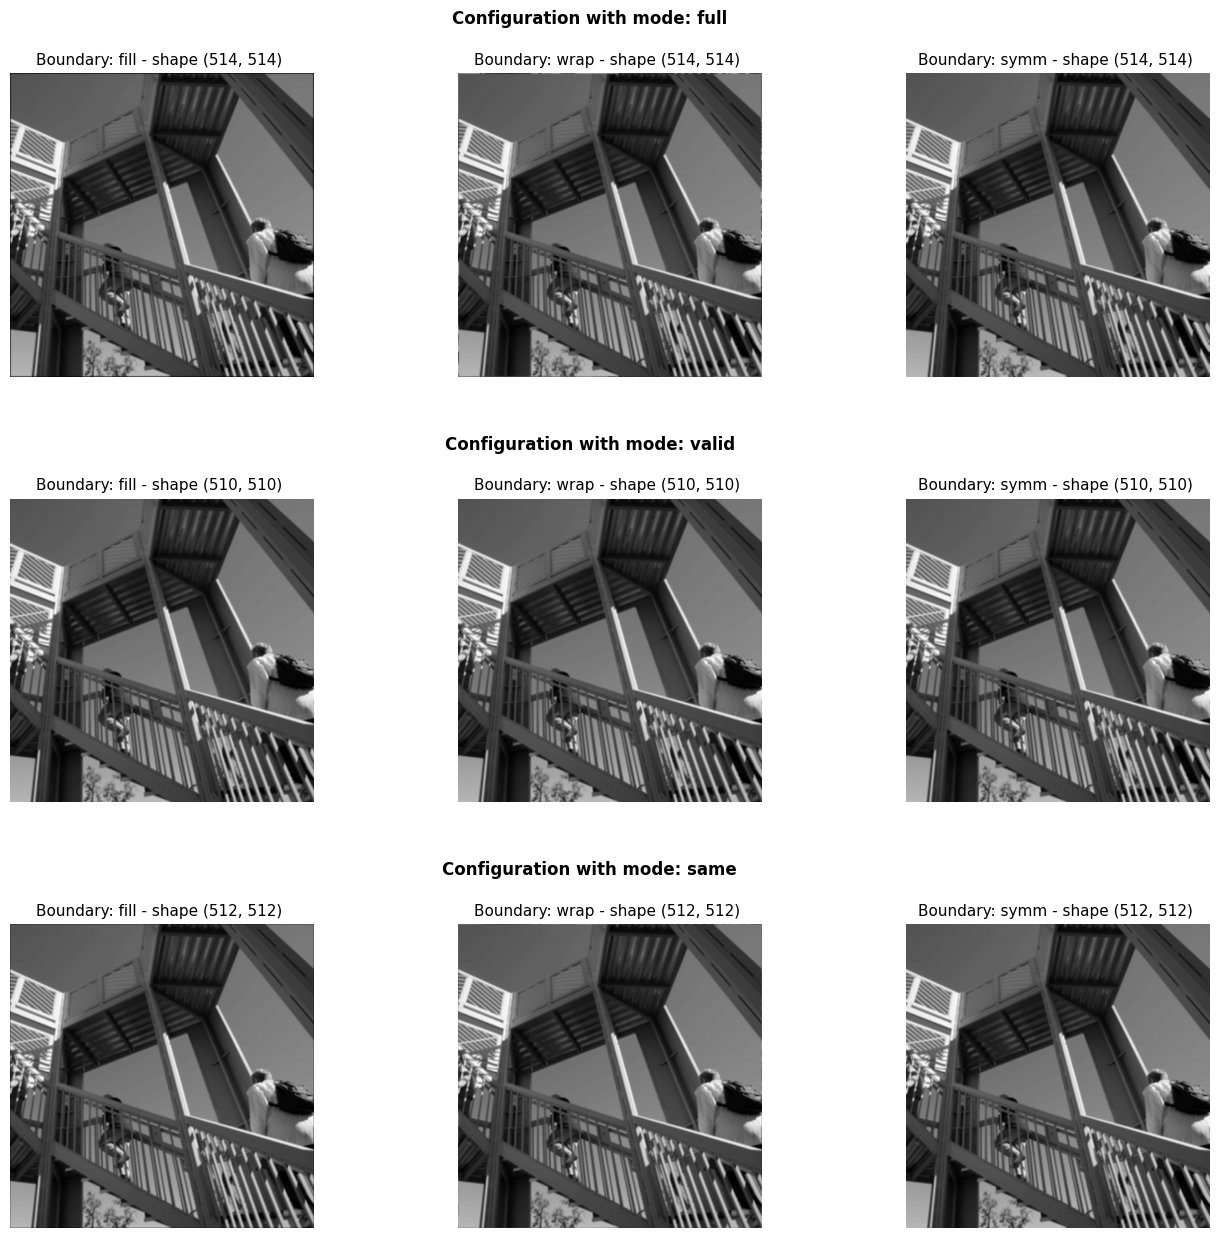

In [ ]:
# Imagen de ejemplo
img = np.uint8(datasets.ascent())
print(f'Tamaño Original: {img.shape}')

# filtro promedio de 3×3
box_fil = np.array([[1, 1, 1],
                   [1, 1, 1],
                   [1, 1, 1]]) * 1/9

# Definamos un filtro gaussiano
img_gaussian_filtered = apply_gaussian_filter(img)

#Definamos los modos y las condiciones de frontera
MODES = ['full', 'valid', 'same']
BOUNDARIES = ['fill', 'wrap', 'symm']

fig, axes = plt.subplots(3, 3, figsize=(16, 15))

# Ajustar espacio entre filas y columnas
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for mode, row in zip(MODES, axes):
    # posición superior de la fila
    y_top = max(ax.get_position().y1 for ax in row)

    # título general centrado arriba de la fila
    fig.text(0.5, y_top + 0.03, f'Configuration with mode: {mode}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Graficamos en base los boundaries y colocamos su respectivo título
    for boundary, column in zip(BOUNDARIES, row):
        img_filtered = signal.convolve2d(img, box_fil, boundary=boundary, mode = mode)
        column.imshow(img_filtered, cmap = 'gray')

        column.set_title(f'Boundary: {boundary} - shape {img_filtered.shape} ', fontsize=11)
        column.set_axis_off()

plt.show()



### **¿Cómo cambia el resultado?**

Basándonos en la documentación de [`scipy.signal.convolve2d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html), el parámetro **`mode`** define el tamaño de la salida. Existen tres opciones:

- **full**: es la opción predeterminada y devuelve la convolución completa de las entradas.  
- **valid**: solo calcula donde el kernel cabe completo en la imagen, dando una salida más pequeña.  
  Es la convolución "pura", sin relleno.
- **same**: la salida mantiene el mismo tamaño que la entrada principal, correspondiendo al resultado centrado del *full output*.  

Por otro lado, el parámetro **`boundary`** define cómo se manejan los bordes de la imagen:  

- **fill**: rellena con un valor fijo (`fillvalue`), que por defecto es 0.  
- **wrap**: aplica condiciones de contorno circulares (el final se conecta con el inicio).  
- **symm**: utiliza condiciones de contorno simétricas, reflejando los bordes.  

---

### **Influencia de la combinación**

La combinación de ambos parámetros determina el aspecto final de la convolución:

- El **`mode`** controla principalmente el **tamaño de la salida** (más grande con *full*, igual que la entrada con *same*, o más pequeño con *valid*).  
- El **`boundary`** influye en **cómo se calculan los píxeles de los bordes**:  
  - Con *fill* se generan bordes oscurecidos o distorsionados por el relleno con ceros.  
  - Con *wrap* la imagen se comporta como si estuviera “enrollada”, por lo que patrones en un borde se repiten en el opuesto.  
  - Con *symm* los bordes se suavizan reflejando los valores cercanos, lo cual suele dar transiciones más naturales.  

En conjunto, elegir un `mode` u otro afecta a la **dimensión del resultado**, mientras que `boundary` modifica la **apariencia y continuidad de los bordes** en la convolución.


## __Experiment with Different Types of Noise AND Applying a Median Filter to Remove Noise__ 

La función `plot_noise_filters(noise_list, img)` genera una comparación visual por filas para cada tipo de ruido indicado en `noise_list`. Para cada ruido crea una imagen ruidosa con `skimage.util.random_noise`, la convierte a formato de 8 bits para visualizarla y muestra tres columnas: la imagen con ruido, la misma imagen suavizada con un filtro Gaussiano mediante `apply_gaussian_filter`, y la misma imagen filtrada con una Mediana usando una ventana circular pequeña. En cada fila añade un título con el nombre del ruido, oculta los ejes para limpiar la vista, ajusta los espacios entre paneles y al final presenta toda la figura con `plt.show()`. El propósito práctico es ofrecer, en una sola grilla, una comparación rápida del efecto de ambos filtros frente a distintos tipos de ruido.


In [65]:
def plot_noise_filters(noise_list, img):
    """
    Plot images with different types of noise and apply filters.

    Parameters
    ----------
    noise_list : list of str
        List of noise modes supported by skimage.util.random_noise.
    img : ndarray
        Input image (2D grayscale) to apply noise and filters.

    Returns
    -------
    None
        Displays a matplotlib figure with noisy images and filtered results.
    """
    fig, axes = plt.subplots(min(len(noise_list), 4), 3, figsize=(16, 5 * len(noise_list)))
    plt.subplots_adjust(hspace=0.25, wspace=0.3)
    
    for noise, row in zip(noise_list, axes):
        # Position of the top of the row for placing a general title
        y_top = max(ax.get_position().y1 for ax in row)

        # General row title
        fig.text(0.5, y_top + 0.02, f'Mode: {noise}',
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

        # Generate noisy image
        img_noise = skimage.util.random_noise(img, mode=noise)
        img_noise = np.uint8(img_noise * 255)

        # Apply filters
        img_gaussian = apply_gaussian_filter(img_noise)
        img_med = skimage.filters.median(img_noise, disk(2))

        # Column 1: noisy image
        row[0].imshow(img_noise, cmap='gray')
        row[0].set_title(f'Noise: {noise}', fontsize=12)
        row[0].axis('off')

        # Column 2: Gaussian filter
        row[1].imshow(img_gaussian, cmap='gray')
        row[1].set_title('Gaussian filter', fontsize=12)
        row[1].axis('off')

        # Column 3: Median filter
        row[2].imshow(img_med, cmap='gray')
        row[2].set_title('Median filter', fontsize=12)
        row[2].axis('off')

    plt.show()

In [58]:
print(disk(2))

[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


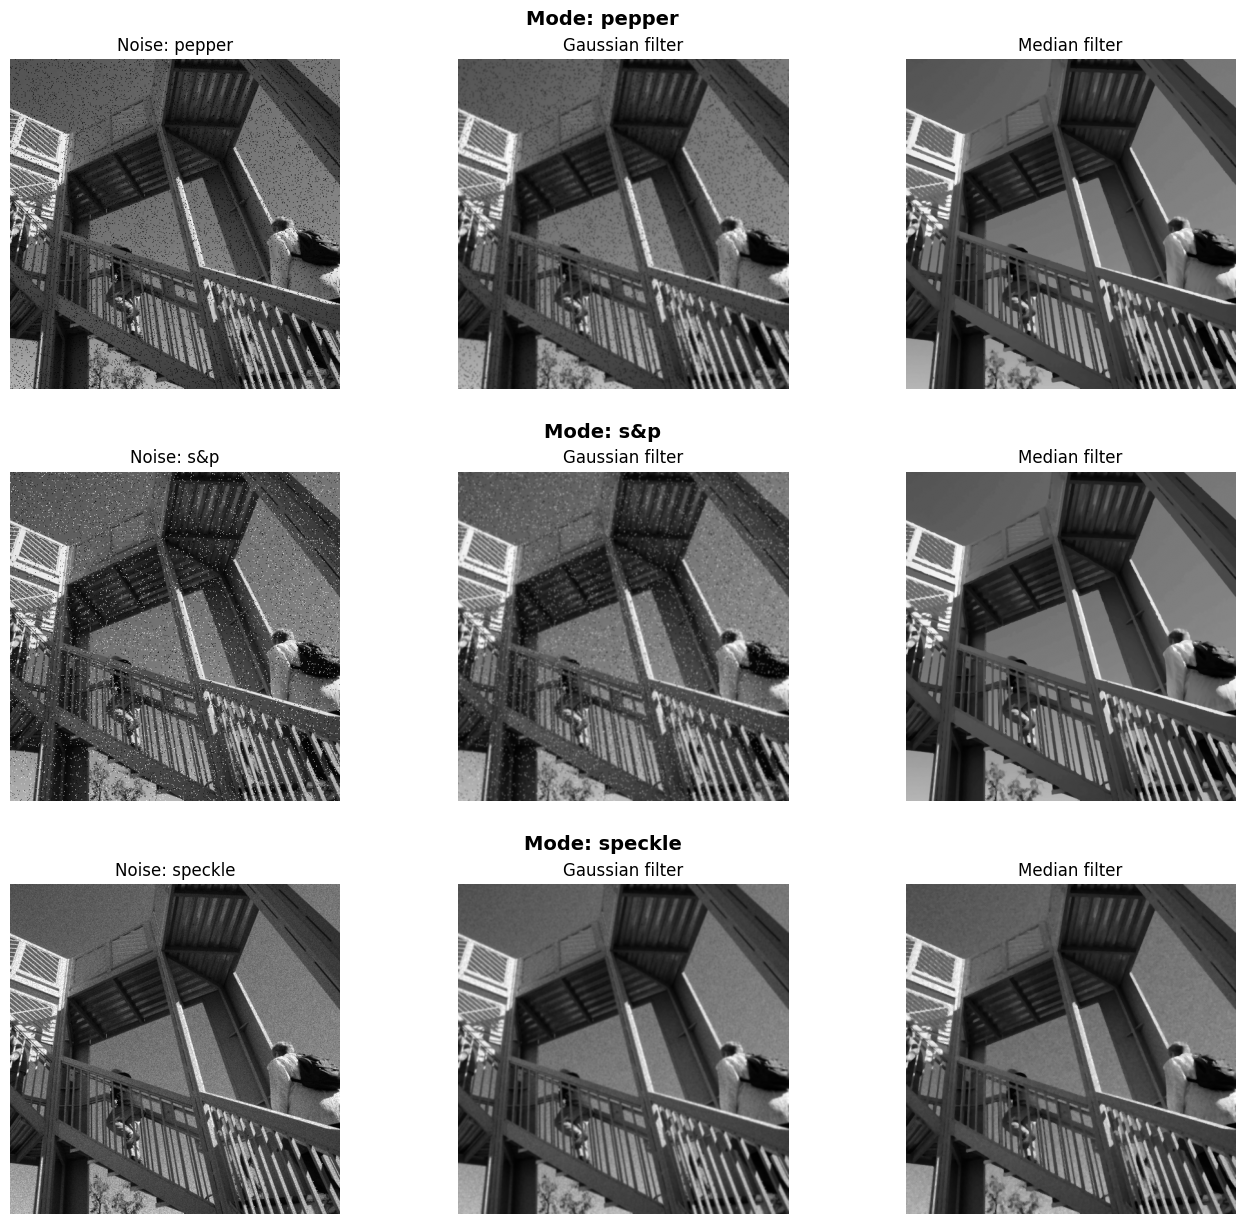

In [66]:
NOISE = ['pepper', 's&p', 'speckle']
plot_noise_filters(NOISE, img)

### __More Types of Noise__


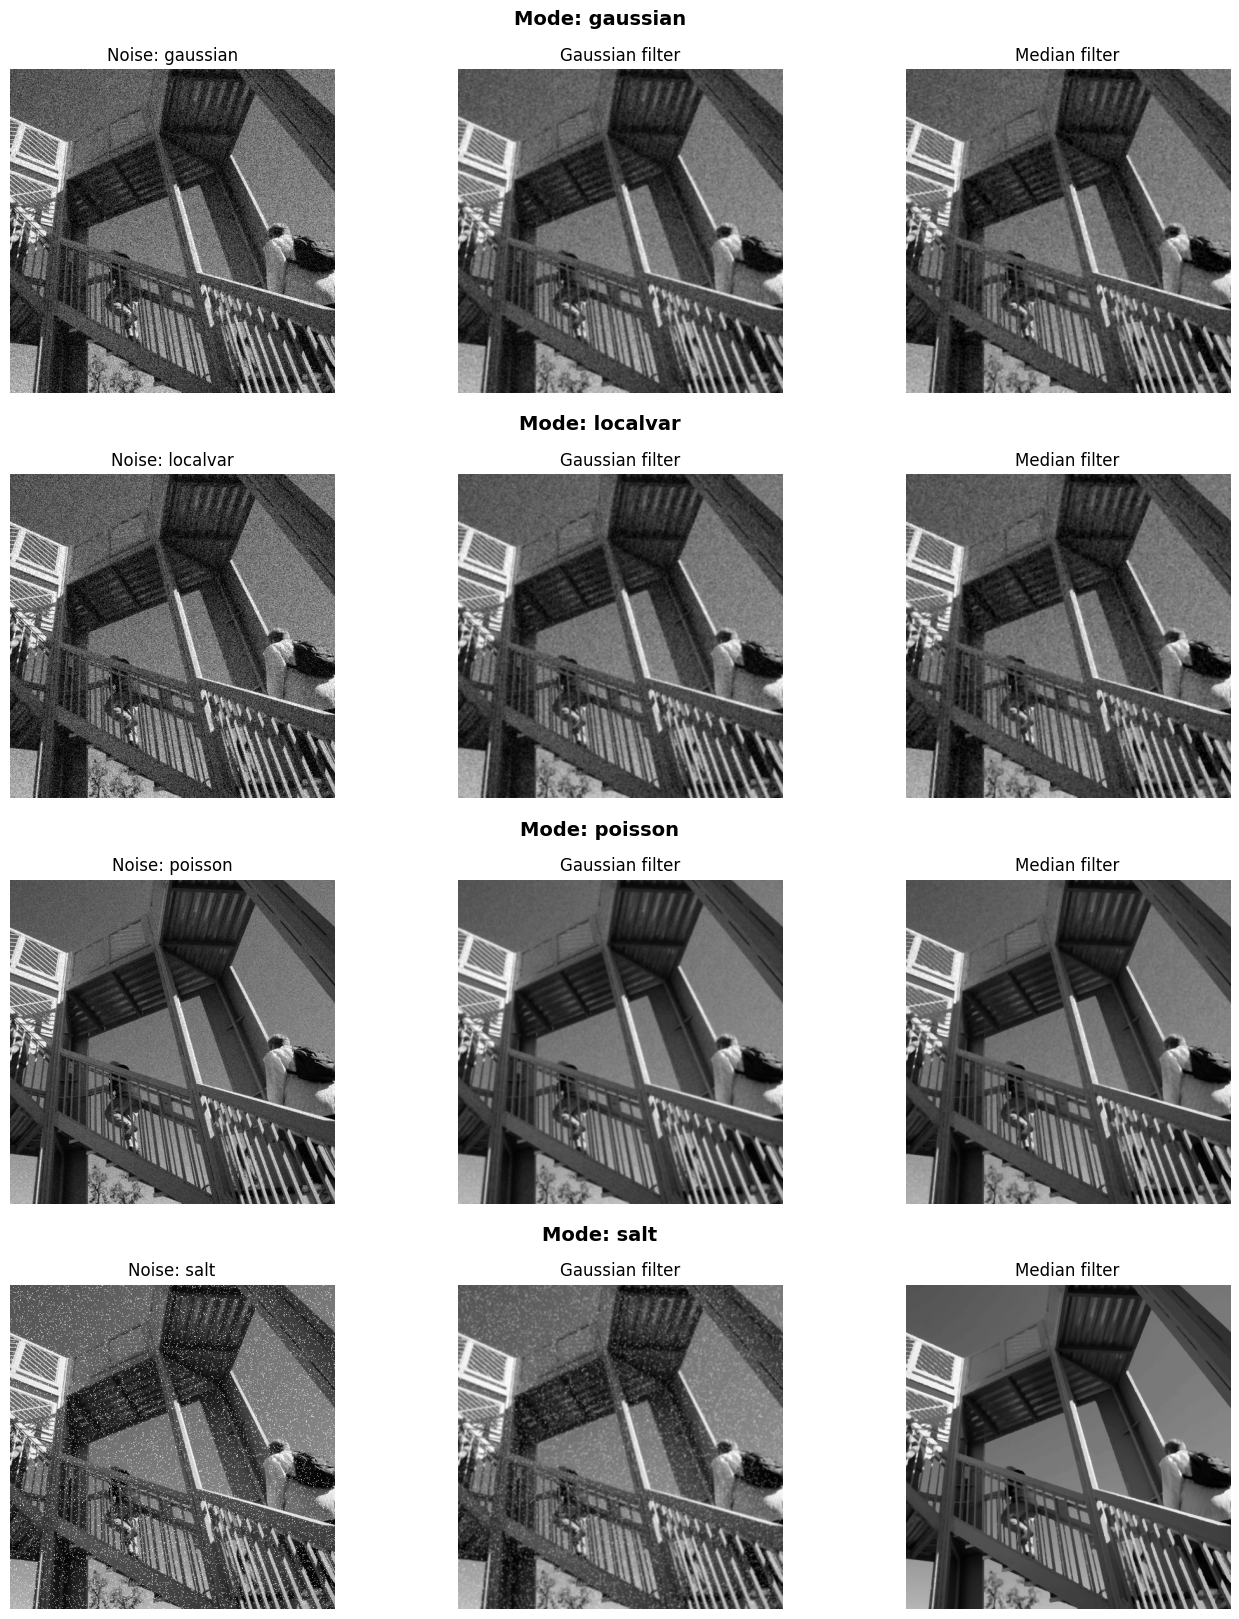

In [67]:
NOISE = ['gaussian', 'localvar', 'poisson', 'salt']
plot_noise_filters(NOISE, img)

## __Further Exploration__

El bloque crea una figura de 2×2 para comparar, sobre la misma imagen, cuatro filtros comunes de procesamiento: Prewitt, Sobel, *unsharp mask* y Laplaciano. Cada filtro se define en un diccionario que guarda la función y sus argumentos, luego un bucle recorre simultáneamente ese diccionario y los ejes de la figura, aplica el filtro con sus parámetros, muestra el resultado en escala de grises, titula cada panel con el nombre del filtro y el tamaño de la salida, oculta los ejes para una vista limpia, ajusta el diseño con `tight_layout()` y finalmente renderiza toda la comparación con `plt.show()`.


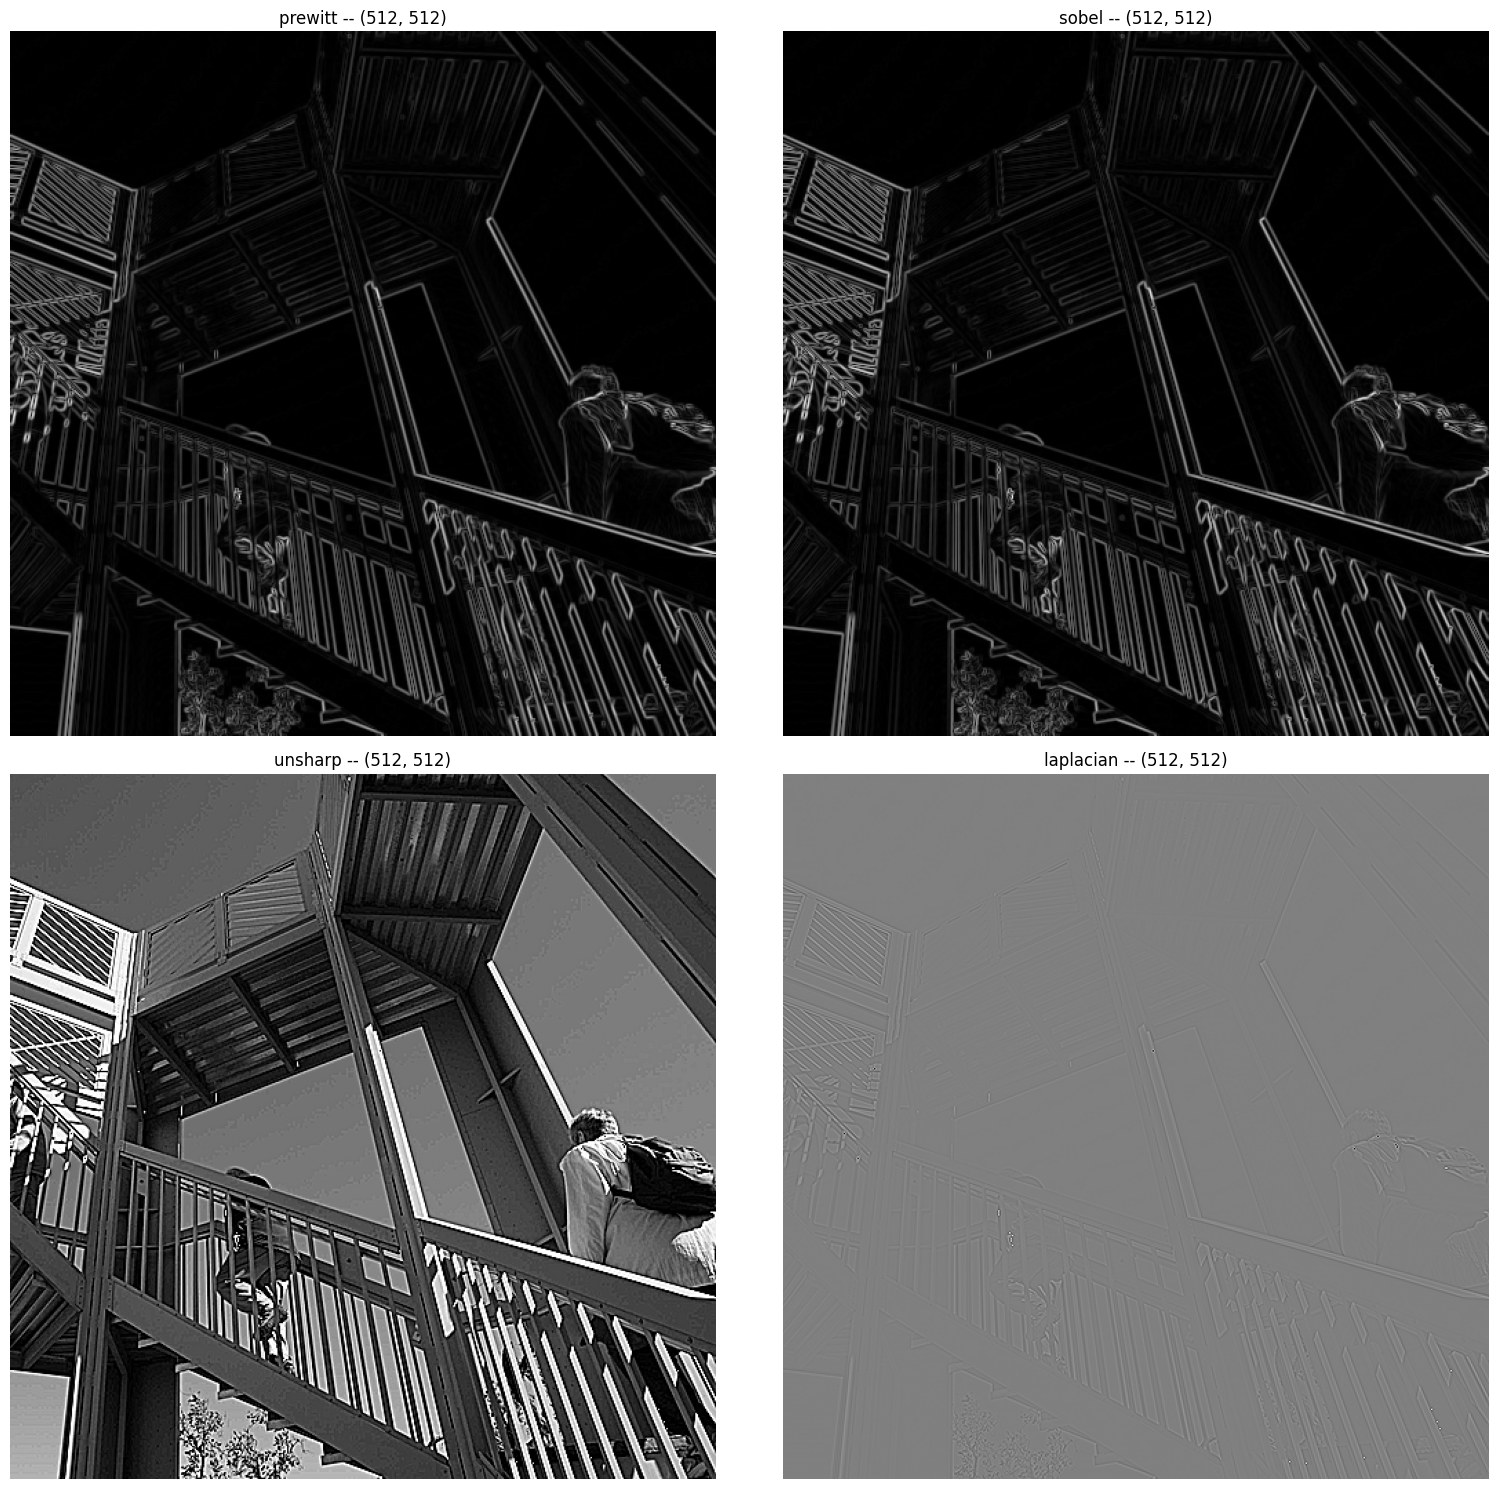

In [69]:
# Crear una figura con una grilla de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 15))

# Diccionario de filtros a aplicar
# Cada entrada guarda la función y sus argumentos clave
filters = {
    "prewitt": {
        "func": skimage.filters.prewitt,
        "kwargs": {"cval": 0.0}
    },
    "sobel": {
        "func": skimage.filters.sobel,
        "kwargs": {"cval": 0.0}
    },
    "unsharp": {
        "func": skimage.filters.unsharp_mask,
        "kwargs": {"radius": 1, "amount": 5}
    },
    "laplacian": {
        "func": skimage.filters.laplace,
        "kwargs": {"ksize": 3}
    }
}

# Iterar sobre los filtros y los ejes correspondientes de la figura
for (name, filter_cfg), ax in zip(filters.items(), axes.flatten()):
    # Aplicar la función de filtrado con sus argumentos
    image_filtered = filter_cfg["func"](img, **filter_cfg["kwargs"])

    # Mostrar la imagen filtrada en escala de grises
    ax.imshow(image_filtered, cmap="gray")

    # Añadir título con el nombre del filtro y el tamaño de la salida
    ax.set_title(f"{name} -- {image_filtered.shape}")

    # Ocultar los ejes (ticks y labels)
    ax.axis("off")

# Ajustar el diseño para evitar solapamiento de títulos
fig.tight_layout()

# Mostrar la figura
plt.show()

### __1. Understanding of Linear Filters__

Los filtros lineales trabajan aplicando una **ventana (kernel)** sobre la imagen y calculando combinaciones de los píxeles vecinos para obtener nuevos valores. En otras palabras, transforman la imagen resaltando o suavizando ciertas características.

- **Low-pass (pasa-bajo):** Con los filtros pasa bajo lo que se busca es suprimir rangos altos de frecuencia. Suavizan la imagen reduciendo el ruido y eliminando detalles finos. Ejemplo: filtro promedio o Gaussiano.  
- **High-pass (pasa-alto):** Los filtros pasa alto son utilizados para detectar los cambios de luminosidad, los cuales se hacen útil a la hora de detectar bordes en la imagen. Resaltan bordes y detalles, eliminando áreas uniformes. Ejemplo: Laplaciano, Unsharp.  
- **Band-pass (pasa-banda):** combinan ambos anteriores, conservando solo ciertas frecuencias intermedias de la imagen. En el caso de la pasa banda, es útil para remover patrones de ruido. Ejemplo: LoG (Laplaciano del Gaussiano).


### __2. Non-Linear Filters__

La diferencia central con los filtros lineales está en los **principios de linealidad** (superposición y homogeneidad) y en cómo se decide el valor filtrado: en los lineales usamos un **kernel fijo** que se aplica igual en toda la imagen, mientras que en los no lineales el resultado **depende de los valores de la vecindad** en cada posición. Por eso, operaciones como la **mediana** no promedian, sino que escogen el valor central de la submatriz actual; en la práctica se sienten más **adaptativas** a la estructura local (bordes, texturas, outliers).

Cuando el objetivo es **reducir ruido sin perder detalles**, los no lineales—en especial la **mediana** frente a ruido impulsivo—han sido más eficaces para **preservar bordes** y mantener formas relevantes. En cambio, los lineales suelen preferirse cuando se busca un comportamiento **predecible y eficiente** (p. ej., suavizar **ruido gaussiano** con Gaussiano) o cuando necesitamos operadores **derivativos** bien definidos para **detección de bordes** (Sobel/Prewitt/Laplaciano). En resumen de nuestra experiencia: recurrimos a **no lineales** cuando la imagen tiene outliers o contornos críticos que no queremos “lavar”, y a **lineales** cuando prima la rapidez, la estabilidad matemática y la compatibilidad con flujos basados en convolución.

### __3. Noise Reduction and Edge Detection__

En el lab, con ruido **salt**, **pepper** y **s&p**, vimos que los **filtros no lineales** (en particular, la **mediana**) fueron los más eficaces para eliminar impulsos sin “lavar” los bordes. Ajustar el **tamaño de la ventana** fue determinante: ventanas pequeñas preservan líneas finas pero limpian menos; ventanas grandes limpian más pero empiezan a perder textura. Cuando el ruido fue más granular o parecido a **gaussiano**, un **suavizado gaussiano** dio resultados estables y eficientes, aunque con riesgo de difuminar contornos si se exagera el σ.

Para la **detección de bordes**, los filtros usados en el notebook (**Prewitt**, **Sobel** y **Laplacian**) funcionaron muy bien y se pueden combinar con **binarización** para realzar todavía más los contornos. Además, **unsharp** mejora significativamente la nitidez de la imagen.

### __4. Practical Considerations__


En las prácticas notamos que lo más importante no fue “cuánto filtrar” sino **cómo organizar el flujo** y **qué versión del filtro usar**. En particular, **Prewitt** y **Sobel** en `skimage` permiten trabajar por componentes **horizontal y vertical** (kernels separados en x e y), lo que reduce cómputo porque se aprovecha la **separabilidad**: en lugar de aplicar un kernel 2D de una sola vez, se hacen dos pasos 1D más ligeros. En el notebook, con imágenes pequeñas, esto **no fue un cuello de botella**; pero a futuro, con imágenes grandes o procesamiento en lote, **sí marca diferencia** (tiempo y consumo de memoria). Asumimos que las funciones de Python ya vienen bastante optimizadas, pero **elegir la variante separable** y evitar pasos redundantes (p. ej., no convertir tipos varias veces ni repetir filtrados equivalentes) ayuda a mantener el flujo ágil.


### __5. Real-World Applications__

En la práctica, la **detección de bordes** suele iniciar con un **preprocesado de suavizado** para retirar el ruido y, a continuación, aplicar los **operadores de borde**. ¿Para qué usarla? Un caso claro es el **reconocimiento facial**, donde los contornos y patrones locales sirven para analizar **expresiones faciales**.  

> **Referencia:** Holder, Ross & Tapamo, Jules-Raymond (2017). *Improved gradient local ternary patterns for facial expression recognition*. **EURASIP Journal on Image and Video Processing**. DOI: [10.1186/s13640-017-0190-5](https://doi.org/10.1186/s13640-017-0190-5).

### __6. Reflection on Challenges and Learning__


El principal reto fue **leer y comprender la documentación** de cada función y preguntarme de forma constante **“¿qué hace este parámetro?”**. Más que “acertar” con una configuración, el objetivo fue **explorar de manera informada** y observar cómo cada ajuste afecta el resultado. Esa práctica, junto con anotar lo observado, me dejó una idea clave: **la calidad del pipeline depende más de entender los fundamentos que de acumular herramientas**; y ese hábito es esencial para aplicar correctamente estas funciones en futuros proyectos, trabajos o tareas.

Este enfoque sienta base para avanzar hacia aplicaciones de **visión por computador** en contextos reales. En industria (por ejemplo, **alimentos**), se puede automatizar la inspección de calidad; en **salud**, apoyar el análisis de imágenes médicas. Dominar filtros y preprocesado facilita, más adelante, integrar modelos de aprendizaje con datos más limpios y señales más estables.  

>**Lecturas relacionadas:**  
> - Monika Modzelewska-Kapitula, Soojin Jun. *The application of computer vision systems in meat science and industry—A review*. **Meat Science**, 2022, 192:108904. DOI: [10.1016/j.meatsci.2022.108904](https://doi.org/10.1016/j.meatsci.2022.108904).  
> - Asif Irshad Khan et al. *Breast cancer based on computer vision and artificial intelligence techniques*. **Measurement**, 2023, 218:113230. DOI: [10.1016/j.measurement.2023.113230](https://doi.org/10.1016/j.measurement.2023.113230).


### __7. Suggestions for Further Exploration__


Todo este tema de **filtros** resulta muy interesante, porque existen tantos que a veces no queda claro hasta qué punto se puede llegar o qué limitaciones tienen. Al final, lo que corresponde es **seguir investigando**: explorar la documentación de `skimage.filters`, probar y comparar cada filtro, y cada vez que surja una idea, cuestionarse si existe un filtro adecuado para ese propósito. En caso de necesitar una guía inicial, siempre se puede **apoyar en un LLM** para orientar el camino y luego profundizar con la investigación.


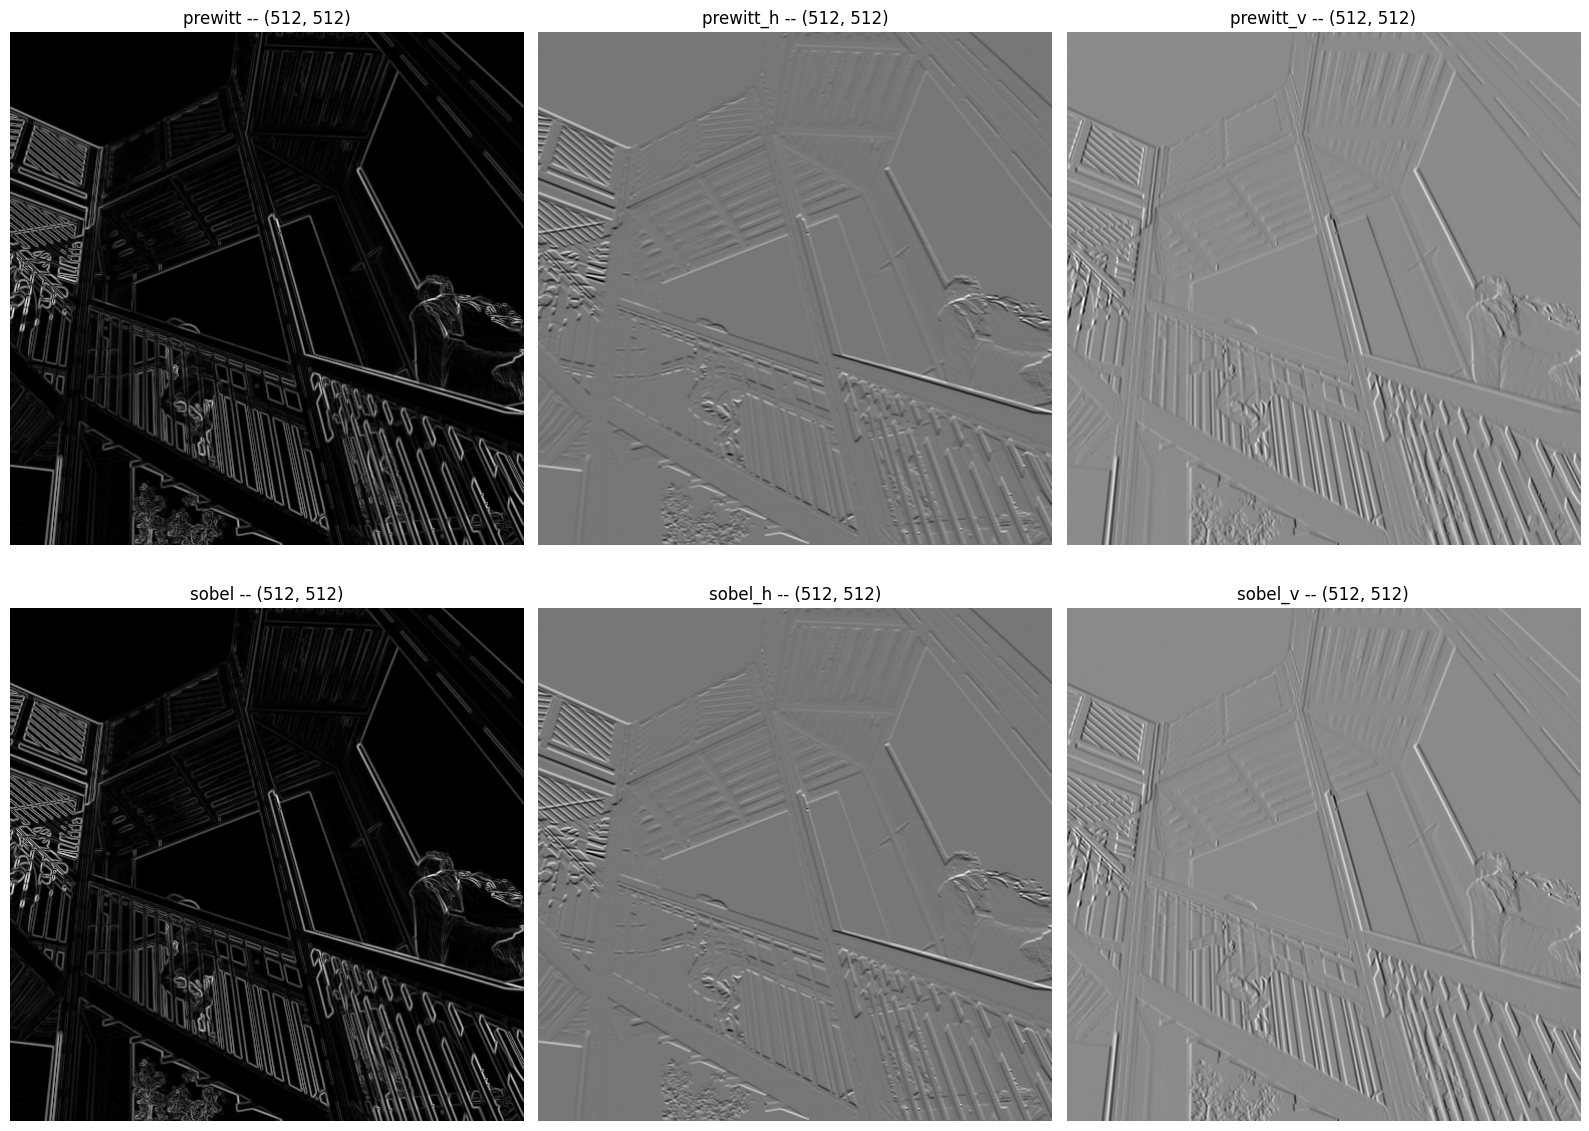

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

filters = {
    "prewitt": skimage.filters.prewitt,
    "prewitt_h": skimage.filters.prewitt_h,
    "prewitt_v": skimage.filters.prewitt_v,
    "sobel": skimage.filters.sobel,
    "sobel_h": skimage.filters.sobel_h,
    "sobel_v": skimage.filters.sobel_v
}

for (name, filter), ax in zip(filters.items(), axes.flatten()):
    image_filtered = filter(img)
    ax.imshow(image_filtered, cmap="gray")
    ax.set_title(f"{name} -- {image_filtered.shape}")
    ax.axis("off")

fig.tight_layout()
plt.show()

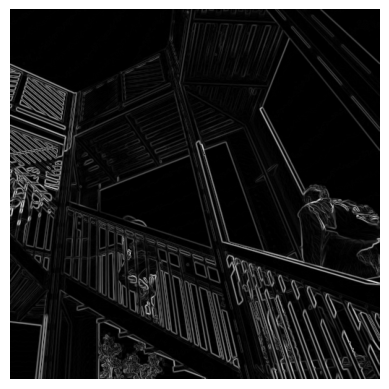

In [71]:
sobel_h_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_v_kernel = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

sobel_h = signal.convolve2d(img, sobel_h_kernel, mode="same", boundary="symm")
sobel_v = signal.convolve2d(img, sobel_v_kernel, mode="same", boundary="symm")
sobel = np.sqrt(sobel_h**2 + sobel_v**2)
plt.imshow(sobel, cmap="gray")
plt.axis("off")
plt.show()